# 02 数据清洗

基于 EDA 发现的数据质量问题，按以下步骤完成清洗：

| 步骤 | 内容 |
|------|------|
| 1 | 加载数据 |
| 2 | 删除重复行 |
| 3 | 修正异常值（age=0，逾期次数 96/98） |
| 4 | 添加缺失标记特征 |
| 5 | 填充缺失值 |
| 6 | 截断极端值（Utilization、DebtRatio、MonthlyIncome） |
| 7 | 构造逾期二值特征 |
| 8 | 清洗结果验证 |
| 9 | 同步清洗测试集并保存 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_raw = pd.read_csv('../data/cs-training.csv').drop(columns=['Unnamed: 0'])
test_raw  = pd.read_csv('../data/cs-test.csv').drop(columns=['Unnamed: 0'])

print('train shape:', train_raw.shape)
print('test  shape:', test_raw.shape)
train_raw.head(3)

train shape: (150000, 11)
test  shape: (101503, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


## 步骤 2：删除重复行

In [2]:
train = train_raw.copy()
test  = test_raw.copy()

dup_before = train.duplicated().sum()
train = train.drop_duplicates()
print(f'删除重复行: {dup_before} 行 -> 剩余 {len(train)} 行')

删除重复行: 609 行 -> 剩余 149391 行


## 步骤 3：修正异常值

### 3.1 age = 0
年龄为 0 不合理，替换为 NaN（后续在缺失值填充步骤中处理）。

### 3.2 逾期次数 96 / 98
这两个值是原数据集的特殊编码，含义不明确（可能是「不适用」或「拒绝回答」），替换为 NaN。

In [3]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

def fix_anomalies(df):
    df = df.copy()
    # age = 0
    age_zero = (df['age'] == 0).sum()
    df.loc[df['age'] == 0, 'age'] = np.nan
    print(f'  age=0 -> NaN: {age_zero} 条')
    # 逾期次数 96 / 98
    for col in late_cols:
        n = df[col].isin([96, 98]).sum()
        df.loc[df[col].isin([96, 98]), col] = np.nan
        print(f'  {col} 96/98 -> NaN: {n} 条')
    return df

print('--- train ---')
train = fix_anomalies(train)
print('--- test ---')
test  = fix_anomalies(test)

print('\ntrain 缺失值情况（修正后）:')
print(train.isnull().sum()[train.isnull().sum() > 0])

--- train ---
  age=0 -> NaN: 1 条
  NumberOfTime30-59DaysPastDueNotWorse 96/98 -> NaN: 225 条
  NumberOfTime60-89DaysPastDueNotWorse 96/98 -> NaN: 225 条
  NumberOfTimes90DaysLate 96/98 -> NaN: 225 条
--- test ---
  age=0 -> NaN: 0 条
  NumberOfTime30-59DaysPastDueNotWorse 96/98 -> NaN: 214 条
  NumberOfTime60-89DaysPastDueNotWorse 96/98 -> NaN: 214 条
  NumberOfTimes90DaysLate 96/98 -> NaN: 214 条

train 缺失值情况（修正后）:
age                                         1
NumberOfTime30-59DaysPastDueNotWorse      225
MonthlyIncome                           29221
NumberOfTimes90DaysLate                   225
NumberOfTime60-89DaysPastDueNotWorse      225
NumberOfDependents                       3828
dtype: int64


## 步骤 4：添加缺失标记特征

缺失本身可能携带信息（MAR），提前记录为二值标记特征，填充后不丢失这一信号。

In [4]:
missing_flag_cols = ['MonthlyIncome', 'NumberOfDependents', 'age'] + late_cols

def add_missing_flags(df):
    df = df.copy()
    for col in missing_flag_cols:
        if df[col].isnull().any():
            df[f'{col}_missing'] = df[col].isnull().astype(int)
    return df

train = add_missing_flags(train)
test  = add_missing_flags(test)

flag_cols = [c for c in train.columns if c.endswith('_missing')]
print('新增标记列:', flag_cols)
print('\ntrain 标记列统计:')
print(train[flag_cols].sum())

新增标记列: ['MonthlyIncome_missing', 'NumberOfDependents_missing', 'age_missing', 'NumberOfTime30-59DaysPastDueNotWorse_missing', 'NumberOfTime60-89DaysPastDueNotWorse_missing', 'NumberOfTimes90DaysLate_missing']

train 标记列统计:
MonthlyIncome_missing                           29221
NumberOfDependents_missing                       3828
age_missing                                         1
NumberOfTime30-59DaysPastDueNotWorse_missing      225
NumberOfTime60-89DaysPastDueNotWorse_missing      225
NumberOfTimes90DaysLate_missing                   225
dtype: int64


## 步骤 5：填充缺失值

| 字段 | 填充策略 | 理由 |
|------|----------|------|
| MonthlyIncome | 中位数 | 严重右偏，均值受极端值影响大 |
| NumberOfDependents | 中位数 | 分布集中在低值 |
| age | 中位数 | 仅少量 age=0 替换为 NaN |
| 逾期次数字段 | 0（众数） | 绝大多数为 0，96/98 是特殊编码而非真实逾期 |

In [5]:
# 用训练集统计量计算填充值
fill_values = {
    'MonthlyIncome':     train['MonthlyIncome'].median(),
    'NumberOfDependents': train['NumberOfDependents'].median(),
    'age':               train['age'].median(),
}
for col in late_cols:
    fill_values[col] = 0

print('填充值:')
for k, v in fill_values.items():
    print(f'  {k}: {v}')

train = train.fillna(fill_values)
test  = test.fillna(fill_values)

remaining_missing = train.isnull().sum().sum()
print(f'\ntrain 剩余缺失值总数: {remaining_missing}')

填充值:
  MonthlyIncome: 5400.0
  NumberOfDependents: 0.0
  age: 52.0
  NumberOfTime30-59DaysPastDueNotWorse: 0
  NumberOfTime60-89DaysPastDueNotWorse: 0
  NumberOfTimes90DaysLate: 0

train 剩余缺失值总数: 0


## 步骤 6：截断极端值

| 字段 | 处理方式 | 理由 |
|------|----------|------|
| RevolvingUtilizationOfUnsecuredLines | clip to [0, 1] | 信用使用率定义上不超过 1 |
| DebtRatio | clip at 99.9 分位数 | 极少量极端值，保留业务含义 |
| MonthlyIncome | clip at 99.9 分位数 | 极少量极端高收入样本 |

In [6]:
# 用训练集计算截断阈值
debt_cap   = train['DebtRatio'].quantile(0.999)
income_cap = train['MonthlyIncome'].quantile(0.999)

print(f'DebtRatio   截断上限 (99.9%): {debt_cap:.2f}')
print(f'MonthlyIncome 截断上限 (99.9%): {income_cap:.2f}')

def clip_outliers(df):
    df = df.copy()
    df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
    df['DebtRatio']      = df['DebtRatio'].clip(upper=debt_cap)
    df['MonthlyIncome']  = df['MonthlyIncome'].clip(upper=income_cap)
    return df

train = clip_outliers(train)
test  = clip_outliers(test)

print(f'\nUtilization>1 残余: {(train["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()}')
print(f'DebtRatio   max: {train["DebtRatio"].max():.2f}')
print(f'MonthlyIncome max: {train["MonthlyIncome"].max():.2f}')

DebtRatio   截断上限 (99.9%): 10658.14
MonthlyIncome 截断上限 (99.9%): 72854.77

Utilization>1 残余: 0
DebtRatio   max: 10658.14
MonthlyIncome max: 72854.77


## 步骤 7：构造逾期二值特征

三个逾期字段高度零膨胀（绝大多数为 0），构造「是否曾发生过该级别逾期」的二值特征，
同时保留原始计数字段。

In [7]:
def add_late_flags(df):
    df = df.copy()
    df['ever_late_30'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] > 0).astype(int)
    df['ever_late_60'] = (df['NumberOfTime60-89DaysPastDueNotWorse'] > 0).astype(int)
    df['ever_late_90'] = (df['NumberOfTimes90DaysLate'] > 0).astype(int)
    df['total_late']   = (df['NumberOfTime30-59DaysPastDueNotWorse']
                         + df['NumberOfTime60-89DaysPastDueNotWorse']
                         + df['NumberOfTimes90DaysLate'])
    return df

train = add_late_flags(train)
test  = add_late_flags(test)

late_feature_cols = ['ever_late_30', 'ever_late_60', 'ever_late_90', 'total_late']
print('新增逾期特征统计（train）:')
print(train[late_feature_cols].describe().T.round(3))

print('\n违约率 vs 逾期标记:')
for col in late_feature_cols[:3]:
    rate = train.groupby(col)['SeriousDlqin2yrs'].mean()
    print(f'  {col}: {rate.to_dict()}')

新增逾期特征统计（train）:
                 count   mean    std  min  25%  50%  75%   max
ever_late_30  149391.0  0.159  0.365  0.0  0.0  0.0  0.0   1.0
ever_late_60  149391.0  0.049  0.216  0.0  0.0  0.0  0.0   1.0
ever_late_90  149391.0  0.054  0.226  0.0  0.0  0.0  0.0   1.0
total_late    149391.0  0.402  1.103  0.0  0.0  0.0  0.0  19.0

违约率 vs 逾期标记:
  ever_late_30: {0: 0.04114483043969509, 1: 0.20402310968666976}
  ever_late_60: {0: 0.05199357999662105, 1: 0.3576005453306067}
  ever_late_90: {0: 0.04729963985764117, 1: 0.41250930752047654}


## 步骤 8：清洗结果验证

In [8]:
# 8.1 缺失值验证
print('=== 缺失值验证 ===')
core_cols = [c for c in train.columns if not c.endswith('_missing')]
missing_core = train[core_cols].isnull().sum()
print(missing_core[missing_core > 0] if missing_core.sum() > 0 else '全部字段无缺失')

=== 缺失值验证 ===
全部字段无缺失


In [9]:
# 8.2 异常值验证
print('=== 异常值验证 ===')
print(f'age==0 残余:        {(train["age"] == 0).sum()}')
print(f'age<18 残余:        {(train["age"] < 18).sum()}')
print(f'Utilization>1 残余: {(train["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()}')
print(f'96/98 残余(90days): {train["NumberOfTimes90DaysLate"].isin([96, 98]).sum()}')

=== 异常值验证 ===
age==0 残余:        0
age<18 残余:        0
Utilization>1 残余: 0
96/98 残余(90days): 0


In [10]:
# 8.3 数据集形状与列名
print('=== 数据集形状 ===')
print(f'原始 train: {train_raw.shape}  ->  清洗后: {train.shape}')
print(f'\n最终列名:')
for c in train.columns:
    print(f'  {c}')

=== 数据集形状 ===
原始 train: (150000, 11)  ->  清洗后: (149391, 21)

最终列名:
  SeriousDlqin2yrs
  RevolvingUtilizationOfUnsecuredLines
  age
  NumberOfTime30-59DaysPastDueNotWorse
  DebtRatio
  MonthlyIncome
  NumberOfOpenCreditLinesAndLoans
  NumberOfTimes90DaysLate
  NumberRealEstateLoansOrLines
  NumberOfTime60-89DaysPastDueNotWorse
  NumberOfDependents
  MonthlyIncome_missing
  NumberOfDependents_missing
  age_missing
  NumberOfTime30-59DaysPastDueNotWorse_missing
  NumberOfTime60-89DaysPastDueNotWorse_missing
  NumberOfTimes90DaysLate_missing
  ever_late_30
  ever_late_60
  ever_late_90
  total_late


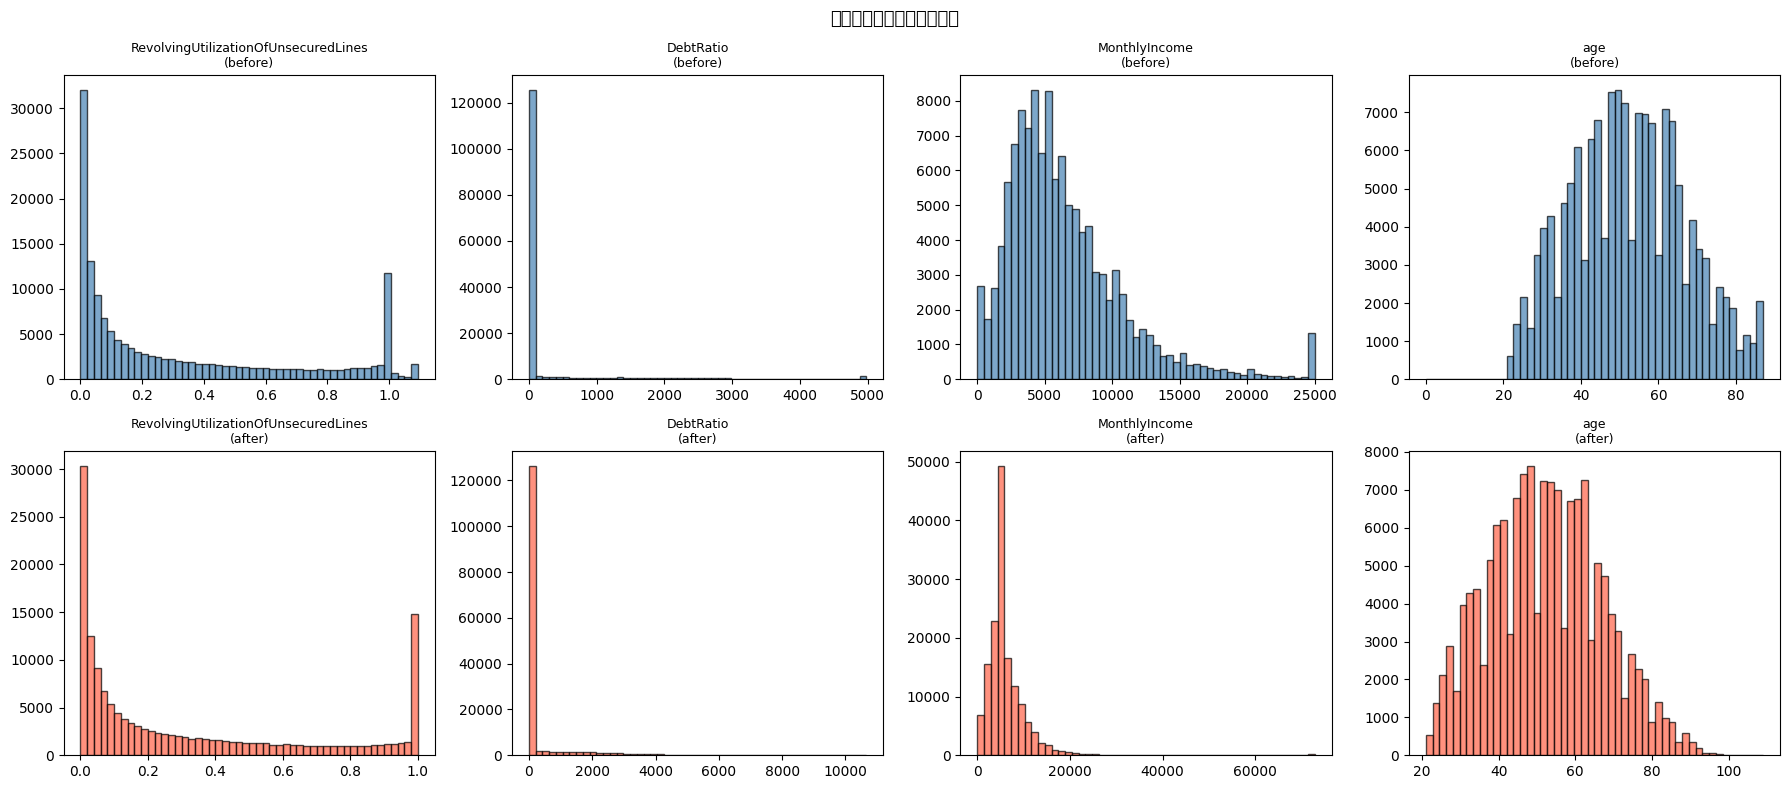

In [11]:
# 8.4 核心字段清洗前后分布对比
compare_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'age',
]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(compare_cols):
    upper = train_raw[col].quantile(0.99)
    axes[0, i].hist(train_raw[col].clip(upper=upper).dropna(), bins=50,
                    color='steelblue', alpha=0.7, edgecolor='k')
    axes[0, i].set_title(f'{col}\n(before)', fontsize=9)

    axes[1, i].hist(train[col], bins=50,
                    color='tomato', alpha=0.7, edgecolor='k')
    axes[1, i].set_title(f'{col}\n(after)', fontsize=9)

plt.suptitle('核心字段清洗前后分布对比', fontsize=13)
plt.tight_layout()
plt.show()

## 步骤 9：保存清洗后数据

In [12]:
import os
os.makedirs('../data/processed', exist_ok=True)

train.to_csv('../data/processed/train_clean.csv', index=False)
test.to_csv('../data/processed/test_clean.csv',  index=False)

print('已保存:')
print(f'  ../data/processed/train_clean.csv  shape={train.shape}')
print(f'  ../data/processed/test_clean.csv   shape={test.shape}')

已保存:
  ../data/processed/train_clean.csv  shape=(149391, 21)
  ../data/processed/test_clean.csv   shape=(101503, 20)


## 数据清洗总结

### 清洗步骤一览

| 步骤 | 操作 | 影响行/字段数 |
|------|------|---------------|
| 删除重复行 | `drop_duplicates()` | 视实际结果 |
| 修正 age=0 | → NaN（后填中位数） | 1 条 |
| 修正逾期 96/98 | → NaN（后填 0） | ~269 条 × 3 字段 |
| 添加缺失标记 | `MonthlyIncome_missing`、`NumberOfDependents_missing`、`age_missing`、三个逾期字段 `_missing` | 新增 6 列 |
| 填充缺失值 | MonthlyIncome/age → 中位数；NumberOfDependents → 中位数；逾期字段 → 0 | 消除全部缺失 |
| 截断极端值 | Utilization clip [0,1]；DebtRatio/MonthlyIncome clip 99.9% 分位数 | 核心 3 字段 |
| 构造逾期特征 | `ever_late_30/60/90`（二值）、`total_late`（计数） | 新增 4 列 |

---

### 输出文件

| 文件 | 说明 |
|------|------|
| `data/processed/train_clean.csv` | 清洗后训练集，含目标变量 |
| `data/processed/test_clean.csv` | 清洗后测试集，无目标变量 |

---

### 后续特征工程方向（在 03_feature_engineering.ipynb 中处理）

- `MonthlyIncome`、`DebtRatio` 对数变换（`log1p`）
- `RevolvingUtilizationOfUnsecuredLines` 分箱
- 年龄分组特征（`age_group`）
- 收入-负债比派生特征